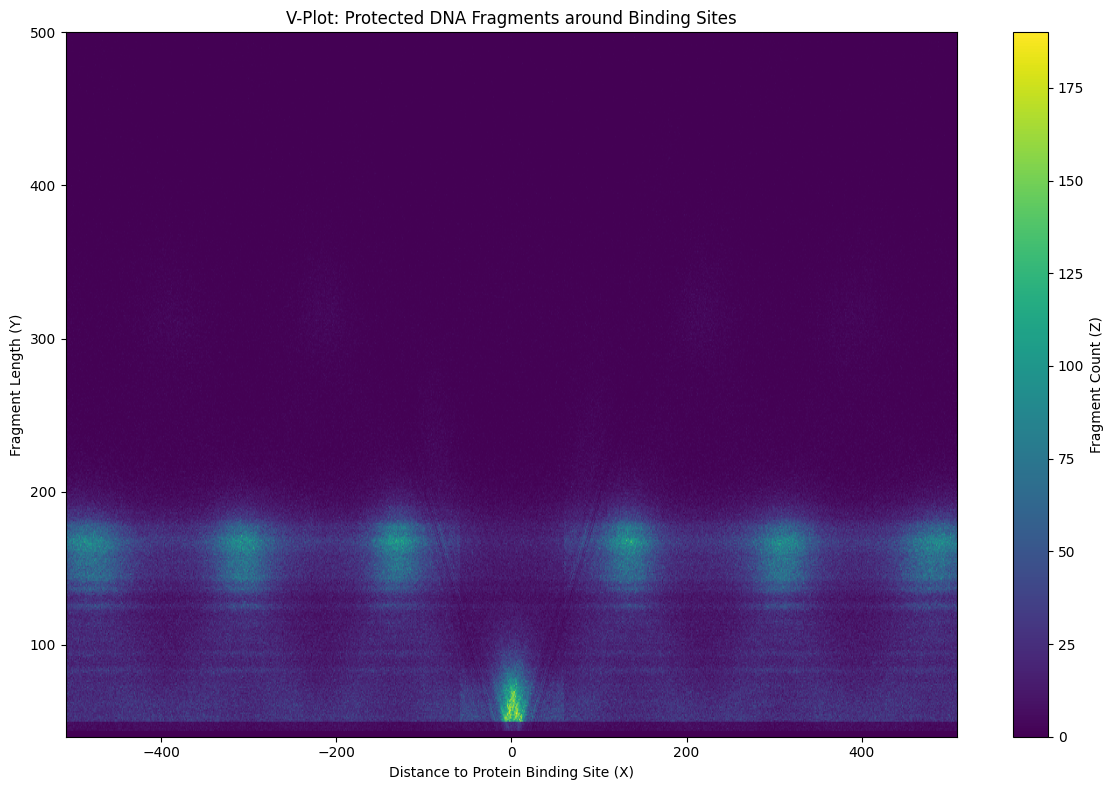

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def parse_input(file_path):
    counter = defaultdict(int)
    x_values = set()
    y_values = set()

    with open(file_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 11:
                continue

            # C1 = center of columns 3 and 4 (0-based index 2 and 3)
            c1 = (int(parts[2]) + int(parts[3])) // 2
            # C2 = center of columns 9 and 10 (index 8 and 9)
            c2 = (int(parts[8]) + int(parts[9])) // 2

            x = c2 - c1
            y = int(parts[9]) - int(parts[8])  # fragment length

            x_values.add(x)
            y_values.add(y)

            counter[(x, y)] += 1

    return counter, sorted(x_values), sorted(y_values)

def build_heatmap_data(counter, x_vals, y_vals):
    x_idx = {val: i for i, val in enumerate(x_vals)}
    y_idx = {val: i for i, val in enumerate(y_vals)}

    heatmap = np.zeros((len(y_vals), len(x_vals)))

    for (x, y), z in counter.items():
        i = y_idx[y]
        j = x_idx[x]
        heatmap[i, j] = z

    return heatmap, x_vals, y_vals

def plot_heatmap(heatmap, x_vals, y_vals):
    plt.figure(figsize=(12, 8))
    plt.imshow(
        heatmap,
        aspect='auto',
        origin='lower',
        extent=[min(x_vals), max(x_vals), min(y_vals), max(y_vals)],
        cmap='viridis'
    )
    plt.colorbar(label='Fragment Count (Z)')
    plt.xlabel('Distance to Protein Binding Site (X)')
    plt.ylabel('Fragment Length (Y)')
    plt.title('V-Plot: Protected DNA Fragments around Binding Sites')
    plt.tight_layout()
    plt.show()

# === MAIN ===
input_file = "data"
counter, x_vals, y_vals = parse_input(input_file)
heatmap, x_vals, y_vals = build_heatmap_data(counter, x_vals, y_vals)
plot_heatmap(heatmap, x_vals, y_vals)
